<a href="https://colab.research.google.com/github/Ronaa-MX/simulacion-esfm/blob/simulacion-I/MetodologiaVentas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simulación de ventas de periódicos

Manejamos al simulación de periódicos, donde tendremos que nuestras variables que son:
* Ventas reales
* Pedidos
* Periódicos no vendidos
* Ventas perdidas

Definiendo nuesto rendimiento como :
$$ \text{Beneficios } = 1.10*\text{Ventas reales}-0.9*\text{Pedido}-0.1*\text{Periódicos no vendidos}-0.20*\text{Ventas Perdidas}$$

Comenzamos considerando que nuestros pedidos son de $50$, de ahí establecemos la variable aleatoria ventas simuladas, esta sera tal que nuestras ventas reales se definiran como:

$$
\text{Ventas Reales} = \begin{cases}
\text{Ventas Simuladas} \text{ si } \text{Ventas Simuladas}\leq \text{Pedido}\\ & \text{Periódicos no vendidos} = \text{Pedido } - \text{Ventas Simuladas} \\   & \text{Ventas perdidas} = 0 \\
\text{Pedido si Ventas Simuladas} > \text{Pedido} \\ & \text{Periódicos no vendidos} = 0 \\   & \text{Ventas perdidas} =\text{Ventas Simuladas} - \text{Pedido }
\end{cases}
$$

In [1]:
# Librerías a utilizar
import numpy as np
import scipy.stats as scistats
import matplotlib.pyplot as plot
import random as rd

In [35]:
def ventas_simuladas():
    random_sale = rd.random()
    match random_sale:
        case _ if random_sale < 0.20:
            return 30
        case _ if random_sale < 0.45:
            return 40
        case _ if random_sale < 0.70:
            return 50
        case _ if random_sale < 0.90:
            return 60
        case _:
            return 70

def sim_beneficio(dias,pedido=50):
  # Coeficientes de la fórmula de beneficio
    PRECIO_VENTA = 1.10      # ingreso por periódico vendido
    COSTO_PEDIDO = 0.90      # costo por periódico pedido
    COSTO_NO_VENDIDO = 0.10  # costo por periódico no vendido
    COSTO_VENTA_PERDIDA = 0.20  # costo por venta perdida

    beneficios = np.zeros(dias)
    promedios_beneficios = np.zeros(dias)
    suma_acum = 0

    for i in range(dias):
        demanda = ventas_simuladas()
        if demanda <= pedido:
            ventas_reales = demanda
            no_vendidos = pedido -  ventas_reales
            ventas_perdidas = 0
        else:
            ventas_reales=pedido
            no_vendidos = 0
            ventas_perdidas =  ventas_reales - pedido

        # Fórmula del beneficio
        beneficio = (PRECIO_VENTA *  ventas_reales) \
                    - (COSTO_PEDIDO * pedido) \
                    - (COSTO_NO_VENDIDO * no_vendidos) \
                    - (COSTO_VENTA_PERDIDA * ventas_perdidas)

        beneficios[i]= beneficio
        suma_acum += beneficio
        promedios_beneficios[i] = suma_acum / (i + 1)

    return beneficios, promedios_beneficios

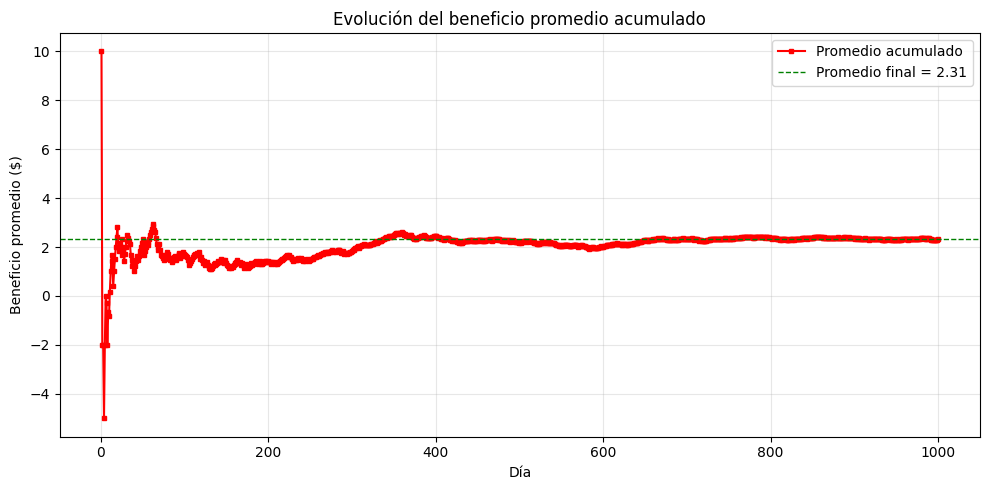

In [37]:
#Simulación
days = 1000
beneficios, promedios = sim_beneficio(days)
#Gráfica
plot.figure(figsize=(10, 5))
plot.plot(range(1, days+1), promedios, marker='s', linestyle='-', markersize=3, color='red', label='Promedio acumulado')
plot.axhline(y=np.mean(beneficios), color='green', linestyle='--', linewidth=1, label=f'Promedio final = {np.mean(beneficios):.2f}')
plot.xlabel('Día')
plot.ylabel('Beneficio promedio ($)')
plot.title('Evolución del beneficio promedio acumulado')
plot.legend()
plot.grid(True, alpha=0.3)
plot.tight_layout()
plot.show()